In [249]:
!pip install datasets

In [250]:

import pandas as pd
import numpy as np
from datetime import date
from dateutil.relativedelta import relativedelta
import os
from tqdm import tqdm
from collections import Counter
from transformers import (
  AutoTokenizer,
  AutoModel,
)
from datasets import Dataset
import torch

In [251]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [252]:
data_dir = "/content/drive/MyDrive/bda2024_mid_dataset"

files = os.listdir(data_dir)
print("View all datasets:")
for f in files:
    print(f)

View all datasets:
bda2024_微股力_財報數據-2年.csv
bda2024_微股力_籌碼數據-2年.csv
bda2024_微股力_個股交易數據-2年.csv
bda2024_微股力_社群PKTD-2年.csv
bda2024_202203-202402_討論數據_ptt.csv
bda2024_202203-202402_討論數據_dcard.csv
bda2024_202203-202402_內容數據_新聞1.csv
bda2024_202203-202402_內容數據_新聞2.csv
bda2024_202203-202402_內容數據_新聞3.csv
bda2024_202203-202402_討論數據_mobile01-1.csv
bda2024_202203-202402_討論數據_mobile01-2.csv
uncategorize.csv
news_df.csv
filtered_stock_data.csv
all_text_data_tsmc.csv


In [253]:
def load_df(filepath, preview=True):
    print(f"\n----- Loading {filepath}... -----")
    df = pd.read_csv(filepath)
    print(f"Size of dataframe: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    if preview:
        print(df.head())
    return df

In [254]:
folder_path = '/content/drive/MyDrive/bda2024_mid_dataset/'

news1_df = load_df(folder_path+"bda2024_202203-202402_內容數據_新聞1.csv", preview=False)
news2_df = load_df(folder_path+"bda2024_202203-202402_內容數據_新聞2.csv", preview=False)
news3_df = load_df(folder_path+"bda2024_202203-202402_內容數據_新聞3.csv", preview=False)
disc_ptt_df = load_df(folder_path+"bda2024_202203-202402_討論數據_ptt.csv", preview=False)

noreply_df = pd.concat([news1_df, news2_df, news3_df, disc_ptt_df], ignore_index=True)

disc_dcard_df = load_df(folder_path+"bda2024_202203-202402_討論數據_dcard.csv", preview=False)
disc_dcard_df.rename(columns={'forum': 'p_type'}, inplace=True)    # Repair column name typo in data
disc_m1_df = load_df(folder_path+"bda2024_202203-202402_討論數據_mobile01-1.csv", preview=False)
disc_m2_df = load_df(folder_path+"bda2024_202203-202402_討論數據_mobile01-2.csv", preview=False)

url_pattern_m = r't=(\d+)'
url_pattern_d = r'p/(\d+)'
disc_m1_df['thread_id'] = disc_m1_df['page_url'].str.extract(url_pattern_m)
disc_m2_df['thread_id'] = disc_m2_df['page_url'].str.extract(url_pattern_m)
disc_dcard_df['thread_id'] = disc_dcard_df['page_url'].str.extract(url_pattern_d)

reply_df = pd.concat([disc_dcard_df, disc_m1_df, disc_m2_df], ignore_index=True)

transaction_df = load_df(folder_path+"bda2024_微股力_個股交易數據-2年.csv", preview=False)
report_df = load_df(folder_path+"bda2024_微股力_財報數據-2年.csv", preview=False)
chip_df = load_df(folder_path+"bda2024_微股力_籌碼數據-2年.csv", preview=False)
transaction_df['stock_symbol'] = transaction_df['stock_symbol'].astype(str)
chip_df['stock_symbol'] = chip_df['stock_symbol'].astype(str)    # Repair mixed data types



----- Loading /content/drive/MyDrive/bda2024_mid_dataset/bda2024_202203-202402_內容數據_新聞1.csv... -----
Size of dataframe: (179449, 9)
Columns: ['id', 'p_type', 's_name', 's_area_name', 'post_time', 'title', 'author', 'content', 'page_url']

----- Loading /content/drive/MyDrive/bda2024_mid_dataset/bda2024_202203-202402_內容數據_新聞2.csv... -----
Size of dataframe: (15114, 9)
Columns: ['id', 'p_type', 's_name', 's_area_name', 'post_time', 'title', 'author', 'content', 'page_url']

----- Loading /content/drive/MyDrive/bda2024_mid_dataset/bda2024_202203-202402_內容數據_新聞3.csv... -----
Size of dataframe: (290929, 9)
Columns: ['id', 'p_type', 's_name', 's_area_name', 'post_time', 'title', 'author', 'content', 'page_url']

----- Loading /content/drive/MyDrive/bda2024_mid_dataset/bda2024_202203-202402_討論數據_ptt.csv... -----
Size of dataframe: (50805, 9)
Columns: ['id', 'p_type', 's_name', 's_area_name', 'post_time', 'title', 'author', 'content', 'page_url']

----- Loading /content/drive/MyDrive/bda2024_

<ipython-input-253-3ba66dfef298>:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)


Size of dataframe: (1154225, 8)
Columns: ['stock_name', 'stock_symbol', 'open', 'high', 'low', 'close', 'volume', 'date']

----- Loading /content/drive/MyDrive/bda2024_mid_dataset/bda2024_微股力_財報數據-2年.csv... -----
Size of dataframe: (16482, 16)
Columns: ['stock_name', 'stock_symbol', 'period', 'gross_profit_margin', 'operating_profit_margin', 'net_profit_margin', 'return_on_equity', 'debt_ratio', 'interest_coverage', 'current_ratio', 'quick_ratio', 'accounts_turnover', 'inventory_turnover', 'eps', 'book_value_per_share', 'date']

----- Loading /content/drive/MyDrive/bda2024_mid_dataset/bda2024_微股力_籌碼數據-2年.csv... -----


<ipython-input-253-3ba66dfef298>:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)


Size of dataframe: (998031, 9)
Columns: ['stock_name', 'stock_symbol', 'foreign_investor_bought', 'foreign_investor_sold', 'investment_trust_bought', 'investment_trust_sold', 'dealer_bought', 'dealer_sold', 'date']


## numerical data

In [255]:
#Only use the stocks appear in both df
left = np.setdiff1d(report_df['stock_name'].unique(), chip_df['stock_name'].unique())
right = np.setdiff1d(chip_df['stock_name'].unique(), report_df['stock_name'].unique())
inner = np.intersect1d(chip_df['stock_name'].unique(), report_df['stock_name'].unique())

all = sum([len(left), len(right), len(inner)])
discard = sum([len(left), len(right)])

print(f'Discarded stocks number: {discard}')
print(f'Retained stocks number: {len(inner)}')
print(f'percent of discarded stocks: {discard/all}')

Discarded stocks number: 635
Retained stocks number: 1834
percent of discarded stocks: 0.25718914540299714


In [256]:
# join on stock_ symbol where df_chip.date in (df_fin.date - 3 months)
report_df['date'] = pd.to_datetime(report_df['date']).dt.date
chip_df['date'] = pd.to_datetime(chip_df['date']).dt.date
noreply_df['post_time'] = pd.to_datetime(noreply_df['post_time']).dt.date
reply_df['post_time'] = pd.to_datetime(reply_df['post_time']).dt.date

df_fin = report_df.loc[report_df['period']=='Q']

tmp = pd.merge(chip_df, df_fin, on='stock_name', suffixes=['_chip', '_fin'], how='inner')

#26 stocks dropped in after this line due to the mismatch of date
df_finchip = tmp.loc[(tmp['date_fin'] - relativedelta(months=3) <= tmp['date_chip']) & (tmp['date_chip'] < tmp['date_fin'])]

## text data

### datas with replies

In [257]:
'''
Remove deleted replies(Dcard)
Remove urls
*Whether to remove replies that are not at the date of main?

*Some replies don't have its main, outer join and fillna?
*Replies and main can have different urls -- fixed, unique id is in url
*Same title problem -- fixed by merging on unique id in url.
*About 40% of the rows don't have any stock name mentioned
*Make stock_name_tagger check stock symbols too
'''

# Separate main content and replies
main = reply_df[reply_df['content_type'] == 'main'][['thread_id', 'post_time', 'title', 'content', 'page_url']].copy()
replies = reply_df[reply_df['content_type'] == 'reply'][['thread_id', 'title', 'content', 'page_url']].copy()

# Remove #公告
main = main[~main['title'].str.contains('#公告', regex=False)]

# Define content to be removed
remove_content = ['已經刪除的內容就像 Dcard 一樣，錯過是無法再相見的！', '此篇文章為轉貼文章，請更新至最新版本觀看完整內容。',
                  '這則留言的文字、圖片或影片，因 交換個人資料（電話、電子郵件、通訊軟體 ID、交友軟體 ID 等），目前已進行移除處理。']

# Filter out the removed content
replies = replies[~replies['content'].isin(remove_content)]

# Regex to remove URLs/ new line symbols
regex = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+|<BR>|\n'

# Remove URLs from 'content' column in replies
main['content'] = main['content'].str.replace(regex, '', regex=True)
replies['content'] = replies['content'].str.replace(regex, '', regex=True)

# Merge main and replies
df_mapped = pd.merge(main, replies, on='thread_id', suffixes=['_main', '_re'], how='outer')

# Group by 'thread_id' and concatenate replies
replies_grouped = df_mapped.groupby('thread_id')['content_re'].agg(lambda x: ' '.join(x.dropna()))

# Join the grouped replies back to the main DataFrame
main = main.join(replies_grouped, on='thread_id').fillna('')
main.rename(columns={'content_re': 'merged_replies'}, inplace=True)
main['all_content'] = main[['title', 'content', 'merged_replies']].agg(' '.join, axis=1)

In [258]:
def process_duplicated(df):
    # Group by 'title' and 'post_time' and find duplicates by these fields
    duplicates = df.duplicated(subset=['title', 'post_time'], keep=False)
    # Work only with duplicated entries
    df_duplicates = df[duplicates]
    # Find the longest 'all_content' within each group of 'title' and 'post_time'
    idx_to_keep = df_duplicates.groupby(['title', 'post_time'])['all_content'].apply(lambda x: x.str.len().idxmax())
    #print(df_duplicates.groupby(['title', 'post_time'])['all_content'].head(5))
    #print(idx_to_keep)
    # Filter out duplicates except for the longest 'all_content' entries
    df_clean = df.drop(df_duplicates.index)  # Drop all duplicates
    df_clean = pd.concat([df_clean, df.loc[idx_to_keep]])  # Concatenate entries to keep with non-duplicate data

    return df_clean

In [259]:
df_reply_merged = process_duplicated(main).drop(columns = "page_url")
df_reply_merged.iloc[0]

thread_id                                                 238238119
post_time                                                2022-03-01
title                                                   #標的 3/1盤前功課
content           週末事件小結1. 烏俄戰爭似乎繼續延燒，短時間無法結束😔戰爭不會是股市利空，只會是人倫悲劇目...
merged_replies           專業給推 感謝分享 存股台積電建議跌到多少可買進呢 謝謝 不知道今天是否將華欣賣掉🥲
all_content       #標的 3/1盤前功課 週末事件小結1. 烏俄戰爭似乎繼續延燒，短時間無法結束😔戰爭不會是股...
Name: 21, dtype: object

In [260]:
# Basic tagger
stock_list = df_finchip['stock_name'].unique()
def stock_name_tagger_1to1(row, stock_list=stock_list):
    title = row['title']
    all_content = row['all_content']

    title_stock = [stock for stock in stock_list if stock in title]
    if len(title_stock) == 1:
        return title_stock[0]

    stock_counts = {}
    for stock in stock_list:
        count = all_content.count(stock)
        if count > 0:
            stock_counts[stock] = count
    if stock_counts:
        return max(stock_counts, key=stock_counts.get)
    return np.nan

In [261]:


!pip install pyahocorasick

In [262]:
# Tagger with Aho–Corasick algorithm(faster)
import ahocorasick

def build_automaton(stock_list):
    # Initialize the automaton
    A = ahocorasick.Automaton()
    for idx, stock in enumerate(stock_list):
        A.add_word(stock, (idx, stock))
    A.make_automaton()
    return A

# Pre-build the automaton with the unique stock names
stock_list = df_finchip['stock_name'].unique()
automaton = build_automaton(stock_list)

def stock_name_tagger_1to1_ac(row, automaton):
    title = row['title']
    all_content = row['all_content']

    # Search for stock names in the title
    title_stocks = set()
    for end_index, (_, stock) in automaton.iter(title):
        title_stocks.add(stock)
    if len(title_stocks) == 1:
        return next(iter(title_stocks))

    # Count occurrences in all_content using the automaton
    content_stock_count = {}
    for end_index, (_, stock) in automaton.iter(all_content):
        if stock in content_stock_count:
            content_stock_count[stock] += 1
        else:
            content_stock_count[stock] = 1

    # Determine the stock name with the maximum count
    if content_stock_count:
        return max(content_stock_count, key=content_stock_count.get)

    return np.nan

In [263]:
tqdm.pandas()
df_reply_1to1 = df_reply_merged.copy()
df_reply_1to1['stock_name'] = df_reply_1to1.progress_apply(stock_name_tagger_1to1, axis=1)
df_reply_1to1['stock_name_ac'] = df_reply_1to1.progress_apply(lambda row: stock_name_tagger_1to1_ac(row, automaton), axis=1)

100%|██████████| 32234/32234 [00:10<00:00, 2998.40it/s]


In [264]:
mentioned_num = df_reply_1to1[~df_reply_1to1['stock_name'].isnull()].shape[0]
unmentioned_num = df_reply_1to1[df_reply_1to1['stock_name'].isnull()].shape[0]
print(f'Rows with stock name: {mentioned_num}\nRows without stock name: {unmentioned_num}\n{mentioned_num/(unmentioned_num+mentioned_num)}% retained')

used_stocks = len(df_reply_1to1['stock_name'].dropna().unique())
used_stocks_2 = len(df_reply_1to1['stock_name_ac'].dropna().unique())
print(f'{used_stocks/len(stock_list)}% of stock names tagged')
print(f'{used_stocks_2/len(stock_list)}% of stock names tagged')

Rows with stock name: 19859
Rows without stock name: 12375
0.6160886020971645% retained
0.6178097345132744% of stock names tagged
0.6338495575221239% of stock names tagged


### datas without replies

In [265]:
#Remove [公告]
df = noreply_df[~noreply_df['title'].str.contains('[公告]', regex=False)][['id', 'post_time', 'title', 'content']].copy()
df['content'] = df['content'].str.replace(regex, '', regex=True).fillna('')
df['all_content'] = df[['title', 'content']].agg(''.join, axis=1)

df_noreply = process_duplicated(df)
df_noreply['stock_name_ac'] = df_noreply.progress_apply(lambda row: stock_name_tagger_1to1_ac(row, automaton), axis=1)
df_noreply['stock_name'] = df_noreply.progress_apply(stock_name_tagger_1to1, axis=1)

100%|██████████| 530699/530699 [05:02<00:00, 1755.26it/s]


In [266]:
all_text_data = pd.concat([df_reply_1to1.dropna()[['post_time', 'all_content', 'stock_name']], df_noreply.dropna()[['post_time', 'all_content', 'stock_name']]])

In [267]:
all_text_data.to_csv('all_text_data.csv', index=False)

In [268]:
all_text_data


,post_time,all_content,stock_name
21,2022-03-01,#標的 3/1盤前功課 週末事件小結1. 烏俄戰爭似乎繼續延燒，短時間無法結束😔戰爭不會是股...,台積電
47,2022-03-01,#請益 台積電跌了要買嗎 股市新手想請問現在為什麼會跌成這樣跟烏俄衝突有關嗎那感覺上進場的時...,台積電
57,2022-03-01,請問圖中買盤是發生什麼事 股市小白來了，直接上圖幾分鐘後想請問這個1000張的大量是從何而來...,大量
62,2022-03-01,#請益 想詢問交割款問題 各位先進好，因為小弟之前都在用美股美商證券，最近把一些些資金移回台...,承業醫
70,2022-03-01,#分享 勸世文 千萬不要碰當沖 今天早上起床看到比特幣大漲想說來當沖板卡股，結果還是玩不贏大...,智原
...,...,...,...
190456,2023-10-14,鴻海科技日、台積電法說會和能源週 台股下週重頭戲（中央社記者張建中台北14日電）台股週線連3...,台積電
233598,2023-02-09,麥可貝瑞張貼2000年比較圖 暗示降息美股也不妙MoneyDJ新聞 2023-02-09 1...,金利
190098,2023-09-27,黃天牧：疫後國際情勢撲朔迷離 看好台股前景（中央社記者謝方娪台北27日電）美國升息近尾聲，但...,精確
194062,2024-02-14,龍年第一盤再現34年高點！謝金河5點看日股破繭而出夢幻劇本：讓全球投資專家跌破很多眼鏡2月1...,台積電


## 股價資料、設定漲跌幅


In [298]:
ase = transaction_df
#ase = stock[stock['stock_symbol'].str.contains('2303')]
#ase['年月日'] = pd.to_datetime(ase['年月日']).dt.date #將日期的時間部分去除
ase['date'] = pd.to_datetime(transaction_df ['date']).dt.date #將日期的時間部分去除
ase = ase.sort_values(by = 'date').reset_index(drop = True)

# 計算各股票的單日漲跌幅度
ase['單日漲跌幅(%)'] = ase.groupby('stock_name')['close'].pct_change()
ase = ase[ase['stock_name'] == '台積電']

# 將單日漲跌幅度分類為漲、跌或持平
def categorize_label(x):
    if x > 0.02:
        return '1'
    elif x < -0.02:
        return '-1'
    else:
        return '0'

# 創建 label 欄位並套用 categorize_label 函數
ase['label'] = ase['單日漲跌幅(%)'].apply(categorize_label)
# type(ase['date'])

ase

<ipython-input-298-8071a2985961>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ase['label'] = ase['單日漲跌幅(%)'].apply(categorize_label)


,stock_name,stock_symbol,open,high,low,close,volume,date,單日漲跌幅(%),label
1502,台積電,2330,599.0,610.0,599.0,604.0,70304,2022-03-01,NaN,0
3552,台積電,2330,601.0,605.0,600.0,601.0,42428,2022-03-02,-0.004967,0
6115,台積電,2330,603.0,607.0,601.0,602.0,37104,2022-03-03,0.001664,0
7566,台積電,2330,595.0,597.0,592.0,595.0,65235,2022-03-04,-0.011628,-1
9112,台積電,2330,580.0,581.0,575.0,576.0,97168,2022-03-07,-0.031933,-1
...,...,...,...,...,...,...,...,...,...,...
1141873,台積電,2330,675.0,688.0,675.0,687.0,31404,2024-02-20,0.013274,1
1146325,台積電,2330,678.0,683.0,678.0,681.0,31981,2024-02-21,-0.008734,0
1147469,台積電,2330,695.0,695.0,685.0,692.0,34269,2024-02-22,0.016153,1
1151618,台積電,2330,701.0,703.0,696.0,697.0,48404,2024-02-23,0.007225,0


In [270]:
ase['label'].value_counts()

label
0     386
1      50
-1     49
Name: count, dtype: int64

## 篩選出 all_text_data 中台積電新聞/討論、股價

In [271]:
all_text_data_tsmc = all_text_data[all_text_data['stock_name'] == '台積電']
all_text_data_tsmc.to_csv('all_text_data_tsmc.csv', index=False)

all_text_data_tsmc = all_text_data_tsmc.dropna(subset=['post_time'])
all_text_data_tsmc.to_csv('all_text_data_tsmc.csv', index=False)

all_text_data_tsmc

,post_time,all_content,stock_name
21,2022-03-01,#標的 3/1盤前功課 週末事件小結1. 烏俄戰爭似乎繼續延燒，短時間無法結束😔戰爭不會是股...,台積電
47,2022-03-01,#請益 台積電跌了要買嗎 股市新手想請問現在為什麼會跌成這樣跟烏俄衝突有關嗎那感覺上進場的時...,台積電
139,2022-03-01,#請益 0050，2330；美股ETF，台股ETF？ 小弟今年大四生，還是個小韭菜，萌生一些...,台積電
356,2022-03-01,#標的 3/2 盤前功課 1. 如預期的想壓台積電，沒想到開盤兩萬張的賣壓輕鬆化解，期貨空單...,台積電
605,2022-03-02,#請益 600以下台積電是不是上天賜予的禮物 大家都知道小妹我台積電狂粉啦從上次買完到現在心...,台積電
...,...,...,...
381629,2023-09-17,高階iPhone 15規格升級 台廠握關鍵技術搶商機（中央社記者鍾榮峰台北2023年9月17...,台積電
179496,2022-12-01,鮑爾放鴿 新台幣爆量狂漲2.69角收近3個月新高（中央社記者潘姿羽台北1日電）美國聯準會鮑爾...,台積電
190456,2023-10-14,鴻海科技日、台積電法說會和能源週 台股下週重頭戲（中央社記者張建中台北14日電）台股週線連3...,台積電
194062,2024-02-14,龍年第一盤再現34年高點！謝金河5點看日股破繭而出夢幻劇本：讓全球投資專家跌破很多眼鏡2月1...,台積電


In [293]:
from datetime import datetime, timedelta
import pandas as pd
import numpy as np

# Convert dates to datetime objects
all_text_data_tsmc['post_time'] = pd.to_datetime(all_text_data_tsmc['post_time'])
ase['date'] = pd.to_datetime(ase['date'])

# Add a new column in all_text_data_tsmc for three days later
all_text_data_tsmc['three_days_later'] = all_text_data_tsmc['post_time'] + timedelta(days=3)

# Merge all_text_data_tsmc with ase using the three_days_later column in all_text_data_tsmc
merged_data = pd.merge(all_text_data_tsmc, ase, left_on='three_days_later', right_on='date', how='inner')




## 建立測試、訓練集


In [294]:
# Filter news content and labels based on the given dates
# 原本只取三個月當作訓練資料
# 後來改取一年
start_date_train, end_date_train = datetime(2022, 3, 1).date(), datetime(2023, 8, 31).date()
start_date_test, end_date_test = datetime(2023, 9, 1).date(), datetime(2023, 11, 30).date()

x_train = merged_data[(merged_data['post_time'].dt.date >= start_date_train) & (merged_data['post_time'].dt.date <= end_date_train)]['all_content']
y_train = merged_data[(merged_data['post_time'].dt.date >= start_date_train) & (merged_data['post_time'].dt.date <= end_date_train)]['label']

x_test = merged_data[(merged_data['post_time'].dt.date >= start_date_test) & (merged_data['post_time'].dt.date <= end_date_test)]['all_content']
y_test = merged_data[(merged_data['post_time'].dt.date >= start_date_test) & (merged_data['post_time'].dt.date <= end_date_test)]['label']

# Save the filtered data
filtered_data_train = pd.DataFrame({'all_content': x_train, 'label': y_train})
filtered_data_train.to_csv('filtered_data_train.csv', index=False)

filtered_data_test = pd.DataFrame({'all_content': x_test, 'label': y_test})
filtered_data_test.to_csv('filtered_data_test.csv', index=False)

In [274]:
merged_data.to_csv('merged_data.csv', index=False)

In [275]:
from google.colab import drive

# 授權訪問 Google Drive
drive.mount('/content/drive')

# 將 merged_data 匯出到 Google Drive 中
merged_data.to_csv('/content/drive/My Drive/merged_data.csv', index=False)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [276]:
merged_data['label'].value_counts()

label
0     10453
1      1453
-1     1388
Name: count, dtype: int64

## Monpa

In [ ]:
!pip install monpa

## Monpa斷詞、取特徵、關鍵字，生成 TF-IDF

1. 獲取不重複的關鍵字：
unique_positive 和 unique_negative 是通過比較看漲和看跌的特徵集來確定的，目的是找出那些僅在一個類別中顯著而在另一個類別中不顯著的詞彙。這有助於提高模型預測的精確度，因為這些詞彙能夠更好地區分不同的股票行情。
這一步確保每個類別都有其獨特的代表性詞彙，這些詞彙將用於構建模型的特徵。

2. 重新生成TF-IDF使用過濾後的關鍵字：
使用過濾後的詞彙重新創建一個TfidfVectorizer。這個新的向量化器將只考慮那些被識別為對預測目標有高度區分性的詞彙。
x_train_tfidf_revised 是對原始訓練集x_train使用這個新的詞彙表重新計算得到的TF-IDF矩陣。這樣可以保證模型訓練使用的特徵是最具區分性和預測價值的。

In [ ]:
pip install emoji


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 433.8/433.8 kB 3.1 MB/s eta 0:00:00


In [295]:
# 斷詞、特徵篩選、關鍵字
import monpa
import re
import emoji
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2

# 使用 Monpa 斷詞
def monpa_tokenizer(text):
    text = emoji.replace_emoji(text, replace='')
    tokens = monpa.cut(text)
    tokens_filtered = [token for token in tokens if not re.match(r'^[^\u4e00-\u9fffA-Za-z]+$', token)]
    return tokens_filtered

# 更新TF-IDF向量化器以包括bigrams和trigrams
tfidf_vectorizer = TfidfVectorizer(tokenizer=monpa_tokenizer, max_features=20000)
x_train_tfidf = tfidf_vectorizer.fit_transform(x_train)

# 分别為三個類別過濾數據
categories = ['1', '0', '-1']
features_dict = {}

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
for category in categories:
    x_train_category = x_train[y_train == category]

    # 計算每個類別的 TF-IDF
    tf_category = tfidf_vectorizer.transform(x_train_category)
    df_category = np.sum(tf_category > 0, axis=0).A1

    # 計算卡方统計量
    chi2score_tf, _ = chi2(tf_category, np.ones((tf_category.shape[0],)))
    chi2score_df, _ = chi2(tf_category > 0, np.ones((tf_category.shape[0],)))

    # 計算 TF-IDF*sqrt(卡方TF)*sqrt(卡方DF)
    importance_scores = tfidf_vectorizer.transform(x_train_category).multiply(np.sqrt(chi2score_tf)).multiply(np.sqrt(chi2score_df))

    # 扁平化重要性分數
    importance_scores = np.array(importance_scores.sum(axis=0)).ravel()

    # 選擇每個類別中最重要的特徵
    top_features = np.argsort(importance_scores)[::-1][:10000]
    unique_features = set(np.array(tfidf_vectorizer.get_feature_names_out())[top_features])

    # 確保特徵在各類別間不重複
    already_selected = set.union(*features_dict.values()) if features_dict else set()
    unique_features = unique_features.difference(already_selected)

    features_dict[category] = unique_features
    print(f"Category {category} key features: {list(unique_features)[:10000]}")

# 合併並保留不重複的特徵
selected_features = list(set().union(*features_dict.values()))

# 使用選定的特徵重新擬合一個 TF-IDF 向量化器
tfidf_vectorizer_revised = TfidfVectorizer(vocabulary=selected_features)
x_train_tfidf_revised = tfidf_vectorizer_revised.fit_transform(x_train)


Category 1 key features: ['玻陶', '工股', '底季', '得分', '國防部', '28萬2395', '商業', '讓', '合作', 'k線', '盤中', '採用', '降評', '9成', '里程碑', '保持', '主掌', '阿姨', '通膨率', '跑', '善用', '企業', '1,469億', '功能', '端倪', '商摩根大通證券', '陳秘順', '中鋼構', '黃猴子', '年代', '由', '終場', '辦理', '好康', '資產', '台新投顧', '山頂', '國一樣', '動產', '預估', ' 2       華航', '急售', '利空重捶', '採取', '電影', '凈空單', '臺北', '蝦皮', '回頭', '工班', '一律', '作對', '電腦展', '重視', '上', '好不', '在望', '論壇', '滑落', '大規', '受訓', '競賽', '中國', '套現', '腰包', '中階版', 'googl', '全球晶', '線形', '老婆', '招人', ' 先平', '反對', '歷程', '市值', '大神們', '行動力', '天爺', '-ky', '驚嚇', '海嘯', '公積', ' 加油', ' 拓', '吞下', '陳鴻文', '一口', '劃', '縮小', '錢景', '包括', '大神', '掃瞄', '超臭', '報復性', '什', '谷哥', '傻眼', '反覆', '線上', '賣給', '誘', '錢文', '股東', '趨穩', '回函', '配息率', '原則', '核電', '進軍', 'morris', ' 楊應超', '解方', '680餘', '點擊', '回軟', 'fom', '藉此', '導入', '分別', '小漲', '平常', '跟跌', '純為', '乖離大', '少數', '人員', '千金', '力度', '進逼', '凶手', '類型', '辛苦', '顧問', '紙', '24日', '跟上', '一段', '五分鐘', ' 賴宏昌', '純粹', '功耗', ' in', '持續擔', '攻陷', '周 道指', '配置', '像', '對立', '翻漲', '陳奕光', '相', '8,0

In [ ]:
!pip install imbalanced-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.0/258.0 kB 2.5 MB/s eta 0:00:00


# 使用篩選特徵生成 TF-IDF 訓練 Model

              precision    recall  f1-score   support

          -1       0.11      0.05      0.06       171
           0       0.85      0.84      0.84      1346
           1       0.05      0.14      0.07        59

    accuracy                           0.72      1576
   macro avg       0.33      0.34      0.33      1576
weighted avg       0.74      0.72      0.73      1576

SVM Classifier Accuracy: 0.7246


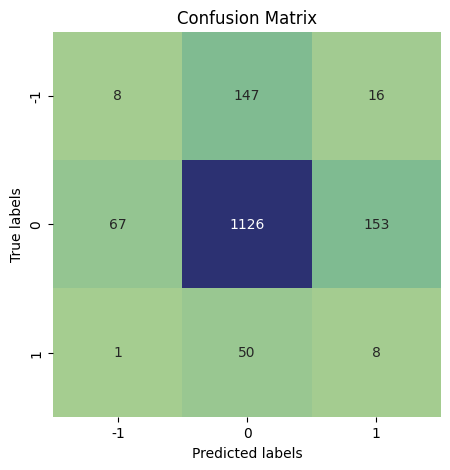

In [299]:
# SVM
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class_weight={'-1': 3, '0': 1, '1': 3}

# SVM 模型
svm_model = SVC(kernel='rbf', class_weight={'-1': 3, '0': 0.8, '1': 4}, random_state=42)
svm_model.fit(x_train_tfidf_revised, y_train)

x_test_tfidf_revised = tfidf_vectorizer_revised.transform(x_test)
y_pred = svm_model.predict(x_test_tfidf_revised)

# 分類報告
print(classification_report(y_test, y_pred))

# 準確率
accuracy_emb = accuracy_score(y_test, y_pred)
print(f"SVM Classifier Accuracy: {accuracy_emb:.4f}")

# 矩陣
cm = confusion_matrix(y_test, y_pred)
class_labels = ['-1', '0', '1']

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap="crest", cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()


              precision    recall  f1-score   support

          -1       0.16      0.08      0.10       171
           0       0.86      0.92      0.89      1346
           1       0.02      0.02      0.02        59

    accuracy                           0.79      1576
   macro avg       0.34      0.34      0.34      1576
weighted avg       0.75      0.79      0.77      1576

Random Forest Classifier Accuracy: 0.7912


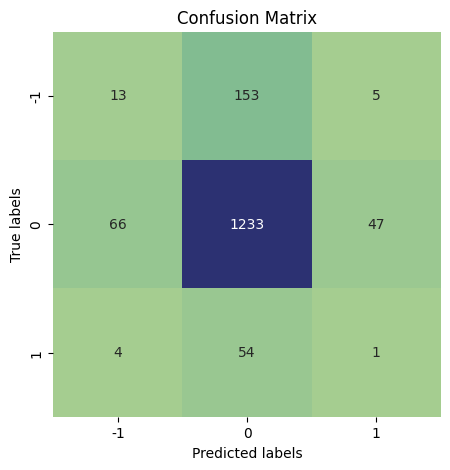

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class_weight = {'-1': 3, '0': 0.7, '1': 3}

rf_model = RandomForestClassifier(n_estimators=100, class_weight=class_weight, random_state=42)

rf_model.fit(x_train_tfidf_revised, y_train)

x_test_tfidf_revised = tfidf_vectorizer_revised.transform(x_test)
y_pred = rf_model.predict(x_test_tfidf_revised)

print(classification_report(y_test, y_pred))

accuracy_rf = accuracy_score(y_test, y_pred)
print(f"Random Forest Classifier Accuracy: {accuracy_rf:.4f}")

cm = confusion_matrix(y_test, y_pred)
class_labels = ['-1', '0', '1']

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap="crest", cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()


              precision    recall  f1-score   support

          -1       0.17      0.12      0.14       171
           0       0.86      0.89      0.87      1346
           1       0.02      0.02      0.02        59

    accuracy                           0.77      1576
   macro avg       0.35      0.34      0.34      1576
weighted avg       0.75      0.77      0.76      1576

Decision Tree Classifier Accuracy: 0.7741


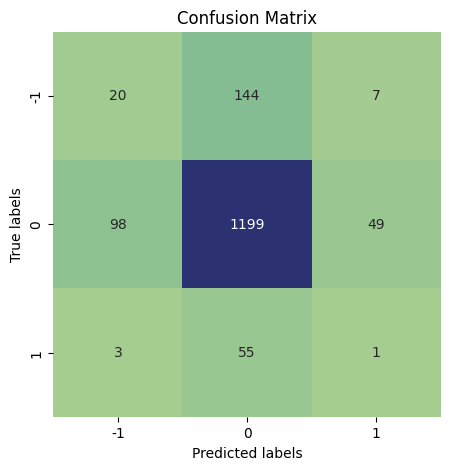

In [ ]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 设置类别权重
class_weight = {'-1': 4, '0': 1, '1': 3}

# 创建决策树模型
dt_model = DecisionTreeClassifier(class_weight=class_weight, random_state=42)

# 训练决策树模型
dt_model.fit(x_train_tfidf_revised, y_train)

# 如果有测试集，进行转换
x_test_tfidf_revised = tfidf_vectorizer_revised.transform(x_test)

# 使用决策树模型进行预测
y_pred = dt_model.predict(x_test_tfidf_revised)

# 显示分类报告
print(classification_report(y_test, y_pred))

# 计算准确率
accuracy_dt = accuracy_score(y_test, y_pred)
print(f"Decision Tree Classifier Accuracy: {accuracy_dt:.4f}")

# 显示混淆矩阵
cm = confusion_matrix(y_test, y_pred)
class_labels = ['-1', '0', '1']

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap="crest", cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


              precision    recall  f1-score   support

          -1       0.16      0.04      0.07       171
           0       0.85      0.95      0.90      1346
           1       0.00      0.00      0.00        59

    accuracy                           0.82      1576
   macro avg       0.34      0.33      0.32      1576
weighted avg       0.75      0.82      0.78      1576

MLP Classifier Accuracy: 0.8185


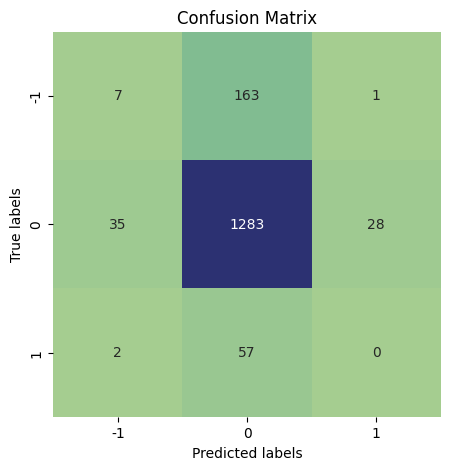

In [ ]:
# MLP
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 创建 MLP 模型
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, activation='relu', solver='adam', random_state=42)

# 训练 MLP 模型
mlp_model.fit(x_train_tfidf_revised, y_train)

# 如果有测试集，进行转换
x_test_tfidf_revised = tfidf_vectorizer_revised.transform(x_test)

# 使用 MLP 模型进行预测
y_pred = mlp_model.predict(x_test_tfidf_revised)

# 显示分类报告
print(classification_report(y_test, y_pred))

# 计算准确率
accuracy_mlp = accuracy_score(y_test, y_pred)
print(f"MLP Classifier Accuracy: {accuracy_mlp:.4f}")

# 显示混淆矩阵
cm = confusion_matrix(y_test, y_pred)
class_labels = ['-1', '0', '1']

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap="crest", cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()


              precision    recall  f1-score   support

          -1       0.11      0.13      0.12       171
           0       0.85      0.81      0.83      1346
           1       0.04      0.07      0.05        59

    accuracy                           0.71      1576
   macro avg       0.34      0.34      0.33      1576
weighted avg       0.74      0.71      0.73      1576

KNN Classifier Accuracy: 0.7100


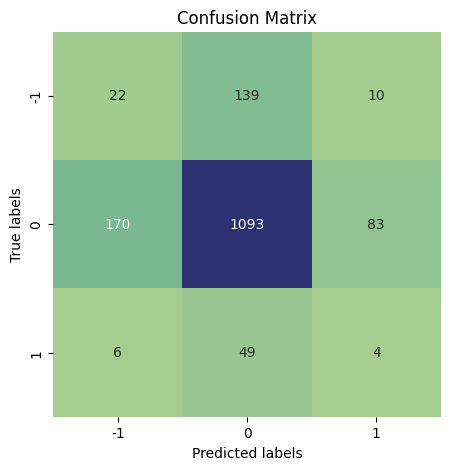

In [ ]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# KNN 模型
knn_model = KNeighborsClassifier(n_neighbors=4)
knn_model.fit(x_train_tfidf_revised, y_train)

x_test_tfidf_revised = tfidf_vectorizer_revised.transform(x_test)
y_pred = knn_model.predict(x_test_tfidf_revised)

print(classification_report(y_test, y_pred))

accuracy_knn = accuracy_score(y_test, y_pred)
print(f"KNN Classifier Accuracy: {accuracy_knn:.4f}")

cm = confusion_matrix(y_test, y_pred)
class_labels = ['-1', '0', '1']

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap="crest", cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()


              precision    recall  f1-score   support

          -1       0.18      0.05      0.07       171
           0       0.85      0.96      0.90      1346
           1       0.00      0.00      0.00        59

    accuracy                           0.82      1576
   macro avg       0.35      0.33      0.33      1576
weighted avg       0.75      0.82      0.78      1576

Voting Classifier Accuracy: 0.8217


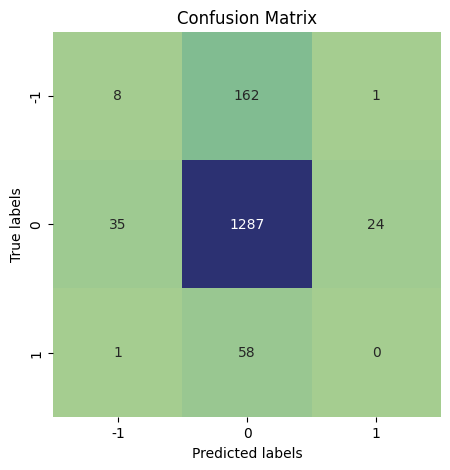

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define individual classifiers
clf1 = RandomForestClassifier(n_estimators=100, random_state=42)
clf2 = DecisionTreeClassifier(random_state=42)
clf3 = SVC(probability=True, random_state=42)  # Enable probability for soft voting
clf4 = KNeighborsClassifier(n_neighbors=2)

# Create a VotingClassifier with soft voting
voting_clf = VotingClassifier(estimators=[
    ('rf', clf1),
    ('dt', clf2),
    ('knn', clf4)
], voting='soft')

voting_clf.fit(x_train_tfidf_revised, y_train)
x_test_tfidf_revised = tfidf_vectorizer_revised.transform(x_test)

y_pred = voting_clf.predict(x_test_tfidf_revised)

print(classification_report(y_test, y_pred))

accuracy_voting = accuracy_score(y_test, y_pred)
print(f"Voting Classifier Accuracy: {accuracy_voting:.4f}")

cm = confusion_matrix(y_test, y_pred)
class_labels = ['-1', '0', '1']

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap="crest", cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()


## 回測 - Random Forest

              precision    recall  f1-score   support

          -1       0.33      0.04      0.06       139
           0       0.65      0.96      0.78       312
           1       0.00      0.00      0.00        28

    accuracy                           0.64       479
   macro avg       0.33      0.33      0.28       479
weighted avg       0.52      0.64      0.52       479

Random Forest Classifier Accuracy: 0.6367


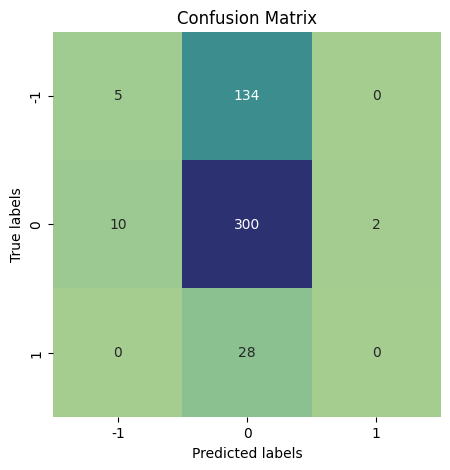

              precision    recall  f1-score   support

          -1       0.26      0.07      0.11       143
           0       0.58      0.96      0.72       501
           1       0.33      0.01      0.02       234

    accuracy                           0.56       878
   macro avg       0.39      0.35      0.29       878
weighted avg       0.46      0.56      0.44       878

Random Forest Classifier Accuracy: 0.5615


<Figure size 640x480 with 0 Axes>

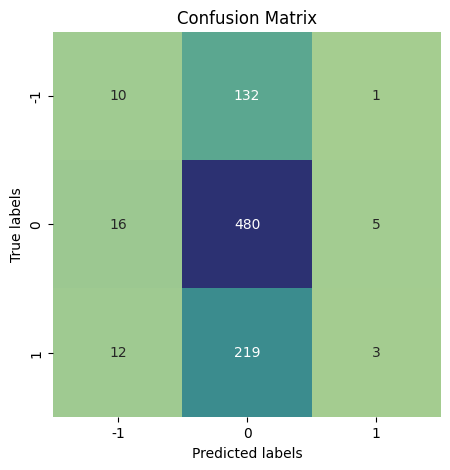

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        55
           0       0.73      0.95      0.82       365
           1       0.00      0.00      0.00        77

    accuracy                           0.70       497
   macro avg       0.24      0.32      0.27       497
weighted avg       0.53      0.70      0.61       497

Random Forest Classifier Accuracy: 0.6982


<Figure size 640x480 with 0 Axes>

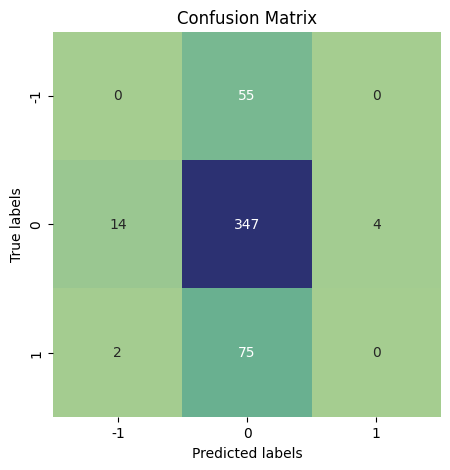

              precision    recall  f1-score   support

          -1       0.26      0.05      0.09        92
           0       0.74      0.94      0.83       340
           1       0.00      0.00      0.00        24

    accuracy                           0.71       456
   macro avg       0.34      0.33      0.31       456
weighted avg       0.61      0.71      0.64       456

Random Forest Classifier Accuracy: 0.7105


<Figure size 640x480 with 0 Axes>

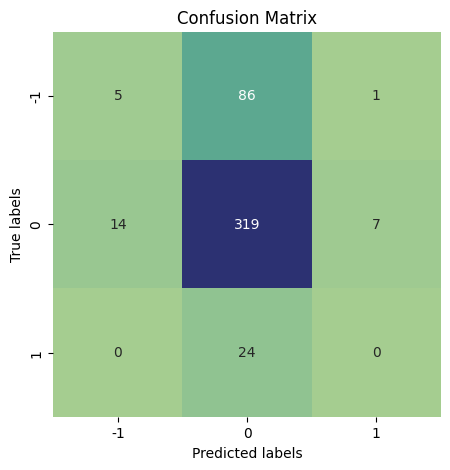

              precision    recall  f1-score   support

          -1       0.12      0.02      0.03       216
           0       0.39      0.93      0.55       289
           1       0.38      0.02      0.04       230

    accuracy                           0.38       735
   macro avg       0.30      0.32      0.21       735
weighted avg       0.31      0.38      0.24       735

Random Forest Classifier Accuracy: 0.3769


<Figure size 640x480 with 0 Axes>

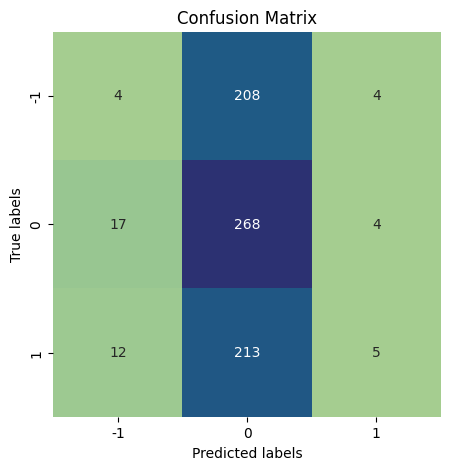

              precision    recall  f1-score   support

          -1       0.10      0.05      0.07        78
           0       0.75      0.93      0.83       539
           1       0.22      0.02      0.04        97

    accuracy                           0.71       714
   macro avg       0.36      0.33      0.31       714
weighted avg       0.61      0.71      0.64       714

Random Forest Classifier Accuracy: 0.7087


<Figure size 640x480 with 0 Axes>

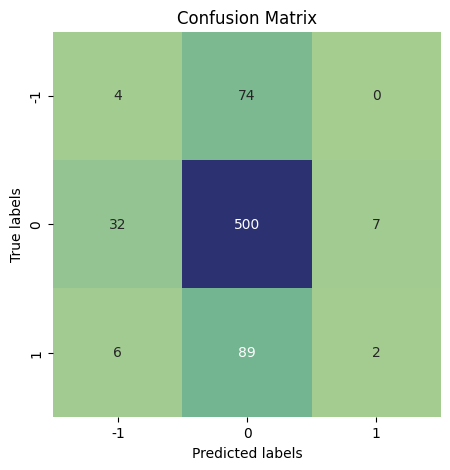

              precision    recall  f1-score   support

          -1       0.12      0.06      0.08        33
           0       0.84      0.97      0.90       433
           1       0.00      0.00      0.00        51

    accuracy                           0.82       517
   macro avg       0.32      0.34      0.33       517
weighted avg       0.71      0.82      0.76       517

Random Forest Classifier Accuracy: 0.8162


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<Figure size 640x480 with 0 Axes>

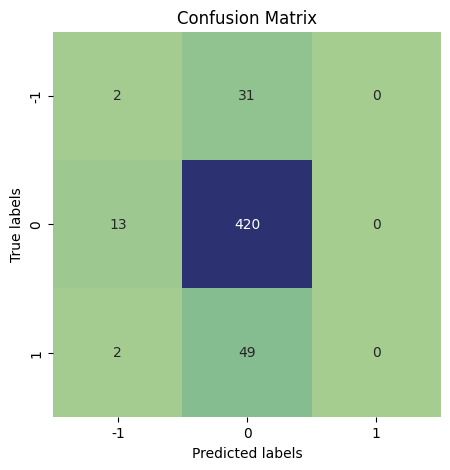

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        11
           0       0.75      0.97      0.85       323
           1       0.00      0.00      0.00        92

    accuracy                           0.73       426
   macro avg       0.25      0.32      0.28       426
weighted avg       0.57      0.73      0.64       426

Random Forest Classifier Accuracy: 0.7324


<Figure size 640x480 with 0 Axes>

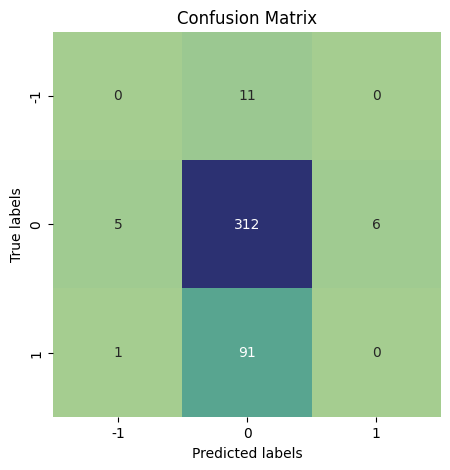

              precision    recall  f1-score   support

          -1       0.17      0.06      0.09        48
           0       0.74      0.93      0.83       298
           1       0.00      0.00      0.00        54

    accuracy                           0.70       400
   macro avg       0.30      0.33      0.31       400
weighted avg       0.57      0.70      0.63       400

Random Forest Classifier Accuracy: 0.7000


<Figure size 640x480 with 0 Axes>

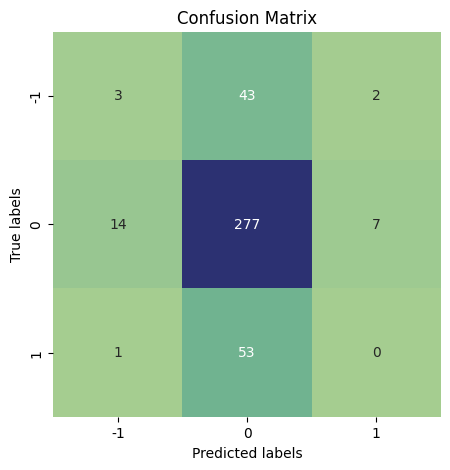

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00         0
           0       0.94      0.97      0.96       390
           1       0.00      0.00      0.00        23

    accuracy                           0.92       413
   macro avg       0.31      0.32      0.32       413
weighted avg       0.89      0.92      0.90       413

Random Forest Classifier Accuracy: 0.9153


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<Figure size 640x480 with 0 Axes>

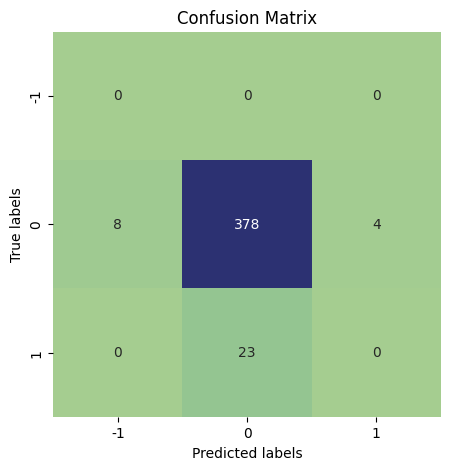

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00         0
           0       1.00      0.97      0.98       506
           1       0.00      0.00      0.00         0

    accuracy                           0.97       506
   macro avg       0.33      0.32      0.33       506
weighted avg       1.00      0.97      0.98       506

Random Forest Classifier Accuracy: 0.9684


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<Figure size 640x480 with 0 Axes>

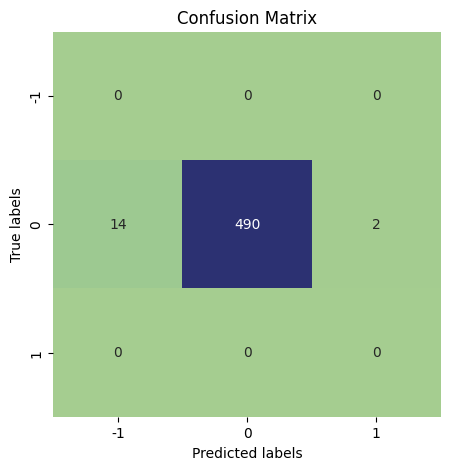

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00         0
           0       0.83      0.96      0.89       457
           1       0.40      0.02      0.04        96

    accuracy                           0.80       553
   macro avg       0.41      0.33      0.31       553
weighted avg       0.76      0.80      0.74       553

Random Forest Classifier Accuracy: 0.7993


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<Figure size 640x480 with 0 Axes>

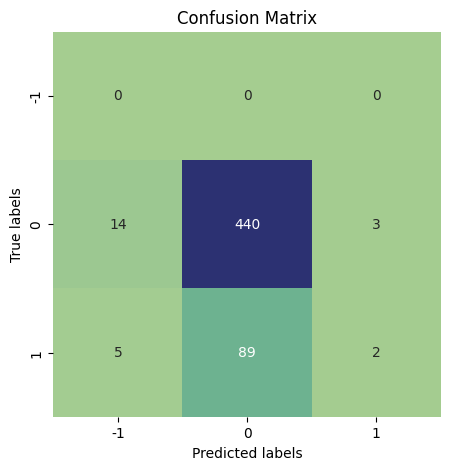

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00         0
           0       0.98      0.96      0.97       435
           1       0.00      0.00      0.00        10

    accuracy                           0.94       445
   macro avg       0.33      0.32      0.32       445
weighted avg       0.95      0.94      0.95       445

Random Forest Classifier Accuracy: 0.9393


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<Figure size 640x480 with 0 Axes>

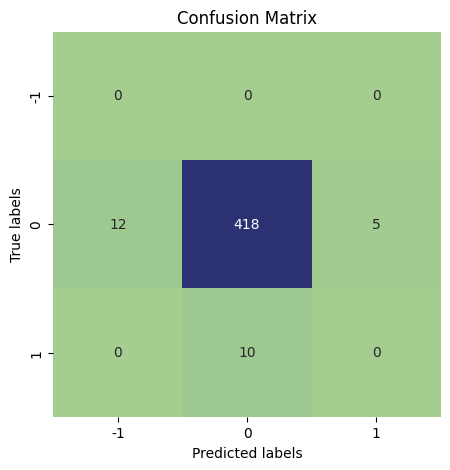

              precision    recall  f1-score   support

          -1       0.13      0.04      0.06        55
           0       0.90      0.96      0.93       566
           1       0.00      0.00      0.00         5

    accuracy                           0.88       626
   macro avg       0.35      0.33      0.33       626
weighted avg       0.83      0.88      0.85       626

Random Forest Classifier Accuracy: 0.8754


<Figure size 640x480 with 0 Axes>

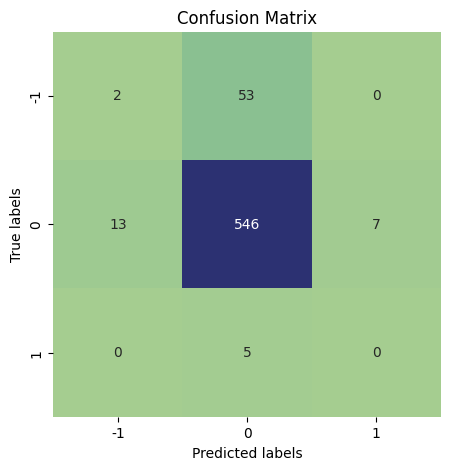

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        28
           0       0.83      0.95      0.88       372
           1       0.44      0.08      0.13        52

    accuracy                           0.79       452
   macro avg       0.42      0.34      0.34       452
weighted avg       0.73      0.79      0.74       452

Random Forest Classifier Accuracy: 0.7898


<Figure size 640x480 with 0 Axes>

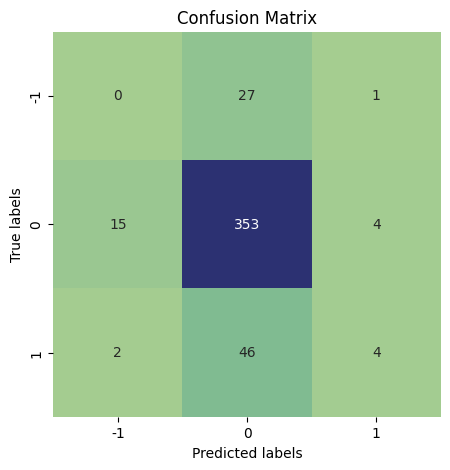

              precision    recall  f1-score   support

          -1       0.05      0.03      0.03        40
           0       0.92      0.95      0.94       465
           1       0.00      0.00      0.00         0

    accuracy                           0.88       505
   macro avg       0.33      0.33      0.32       505
weighted avg       0.85      0.88      0.87       505

Random Forest Classifier Accuracy: 0.8812


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<Figure size 640x480 with 0 Axes>

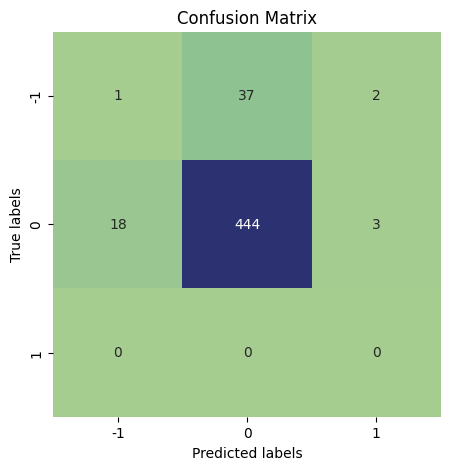

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00       131
           0       0.73      0.97      0.84       377
           1       0.00      0.00      0.00         3

    accuracy                           0.72       511
   macro avg       0.24      0.32      0.28       511
weighted avg       0.54      0.72      0.62       511

Random Forest Classifier Accuracy: 0.7162


<Figure size 640x480 with 0 Axes>

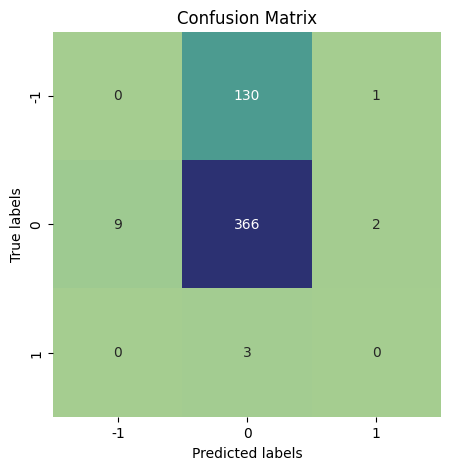

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00         0
           0       0.91      0.96      0.93       442
           1       0.00      0.00      0.00        43

    accuracy                           0.87       485
   macro avg       0.30      0.32      0.31       485
weighted avg       0.83      0.87      0.85       485

Random Forest Classifier Accuracy: 0.8722


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<Figure size 640x480 with 0 Axes>

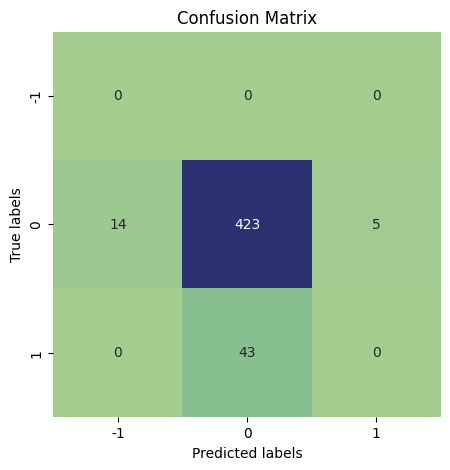

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00         0
           0       1.00      0.96      0.98       512
           1       0.00      0.00      0.00         0

    accuracy                           0.96       512
   macro avg       0.33      0.32      0.33       512
weighted avg       1.00      0.96      0.98       512

Random Forest Classifier Accuracy: 0.9590


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<Figure size 640x480 with 0 Axes>

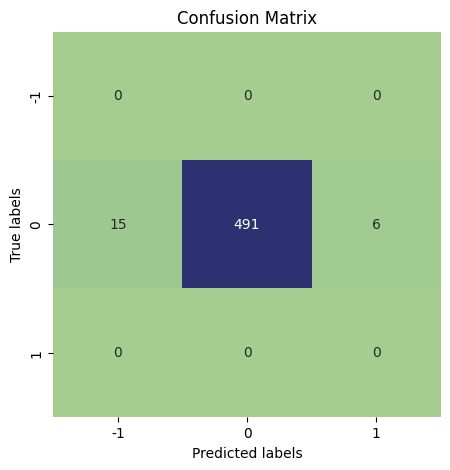

              precision    recall  f1-score   support

          -1       0.10      0.13      0.11        15
           0       0.78      0.96      0.86       585
           1       0.18      0.01      0.02       154

    accuracy                           0.75       754
   macro avg       0.35      0.37      0.33       754
weighted avg       0.64      0.75      0.68       754

Random Forest Classifier Accuracy: 0.7520


<Figure size 640x480 with 0 Axes>

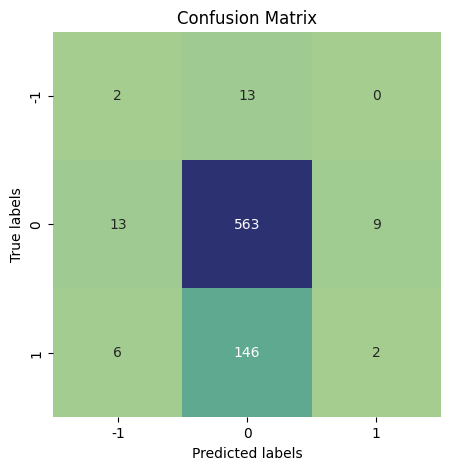

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00         9
           0       0.96      0.96      0.96       348
           1       0.00      0.00      0.00         5

    accuracy                           0.93       362
   macro avg       0.32      0.32      0.32       362
weighted avg       0.92      0.93      0.92       362

Random Forest Classifier Accuracy: 0.9254


<Figure size 640x480 with 0 Axes>

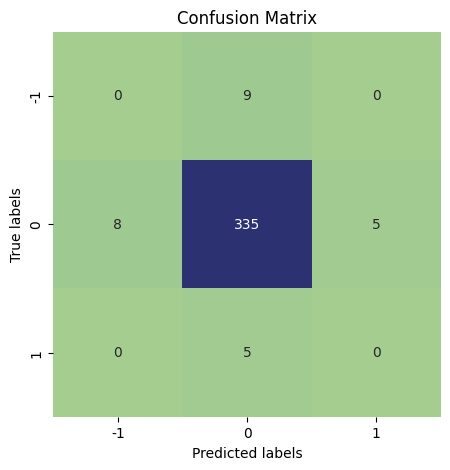

Average Accuracy:  0.7778381276211123


<Figure size 640x480 with 0 Axes>

In [280]:

# 斷詞、特徵篩選、關鍵字
import monpa
import re
import emoji
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2

merged_data['post_time'] = pd.to_datetime(merged_data['post_time']).dt.date
start_date_train = datetime(2022, 3, 1).date()
end_date_test = datetime(2022, 6, 30).date()
accuracyL = []

# 前3個月用於訓練，後1個月用於測試
while end_date_test <= datetime(2024, 2, 28).date():
  end_date_train = (datetime.combine(start_date_train, datetime.min.time()) + relativedelta(months=3) - timedelta(days=1)).date()
  start_date_test = (datetime.combine(start_date_train, datetime.min.time()) + relativedelta(months=3)).date()

  x_train = merged_data[(merged_data['post_time'] >= start_date_train) & (merged_data['post_time'] <= end_date_train)]['all_content']
  y_train = merged_data[(merged_data['post_time'] >= start_date_train) & (merged_data['post_time'] <= end_date_train)]['label']

  x_test = merged_data[(merged_data['post_time'] >= start_date_test) & (merged_data['post_time'] <= end_date_test)]['all_content']
  y_test = merged_data[(merged_data['post_time'] >= start_date_test) & (merged_data['post_time'] <= end_date_test)]['label']

  # 使用 Monpa 斷詞
  def monpa_tokenizer(text):
      text = emoji.replace_emoji(text, replace='')
      tokens = monpa.cut(text)
      tokens_filtered = [token for token in tokens if not re.match(r'^[^\u4e00-\u9fffA-Za-z]+$', token)]
      return ' '.join(tokens_filtered)


  x_train_processed = x_train.apply(monpa_tokenizer)
  x_test_processed = x_test.apply(monpa_tokenizer)

  x_train_tfidf_matrix = tfidf_vectorizer_revised.fit_transform(x_train_processed)
  x_test_tfidf_matrix = tfidf_vectorizer_revised.transform(x_test_processed)

  y_test_pred_rf = rf_model.predict(x_test_tfidf_matrix)

  print(classification_report(y_test, y_test_pred_rf))
  accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
  print(f"Random Forest Classifier Accuracy: {accuracy_rf:.4f}")
  accuracyL.append(accuracy_rf)

  cm = confusion_matrix(y_test, y_test_pred_rf)
  class_labels = ['-1', '0','1']
  plt.figure(figsize=(5, 5))
  sns.heatmap(cm, annot=True, fmt='g', cmap="crest", cbar=False,
              xticklabels=class_labels, yticklabels=class_labels)
  plt.xlabel("Predicted labels")
  plt.ylabel("True labels")
  plt.title("Confusion Matrix")
  plt.show()
  save_path = "/content/drive/MyDrive/BDA_backtest/" + str(start_date_test).replace("-", "") + ".png"
  plt.savefig(save_path, bbox_inches="tight", pad_inches=0.1)

  # print(start_date_train, end_date_train)
  # print(start_date_test, end_date_test)
  # print()

  start_date_train = (datetime.combine(start_date_train, datetime.min.time()) + relativedelta(months=1)).date()
  end_date_test = (datetime.combine(end_date_test, datetime.min.time()) + relativedelta(months=1)).date()

print("Average Accuracy: ", sum(accuracyL)/len(accuracyL))

In [281]:
print(accuracyL)
print(len(accuracyL))

[0.6367432150313153, 0.5615034168564921, 0.6981891348088531, 0.7105263157894737, 0.3768707482993197, 0.7086834733893558, 0.816247582205029, 0.7323943661971831, 0.7, 0.9152542372881356, 0.9683794466403162, 0.7992766726943942, 0.9393258426966292, 0.8753993610223643, 0.7898230088495575, 0.8811881188118812, 0.7162426614481409, 0.8721649484536083, 0.958984375, 0.7519893899204244, 0.925414364640884]
21
